# Beam Sweeping with Antenna Panels and Arrays

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, Markdown, display

from neoradium import AntennaElement, AntennaPanel, AntennaArray

## A Linear Antenna Panel with Dual Polarization

In [2]:
# Create a linear antenna panel with 8 elements (4 antenna positions with dual polarization)
txAntenna=AntennaPanel([1,4], polarization='x')
# Get beam sweeping information:
weights, beams = txAntenna.getSweepingBeams(numTheta=1, numPhi=8, polStrategy="equal")
# 'weights' is a 'numPorts × numBeams' complex matrix.
numPorts, numBeams = weights.shape
print(f"Number of ports: {numPorts}")
print(f"{len(beams[0])} Beams:")
print("  Beam    Theta     Phi     Pol")
print("  ----    -----    -----    ---")
for i in range(numBeams):
    print(f"   {i}     {np.round(beams[0][i],1):5.1f}     {np.round(beams[1][i],1):5.1f}     {beams[2][i]}")
   

Number of ports: 8
8 Beams:
  Beam    Theta     Phi     Pol
  ----    -----    -----    ---
   0      90.0     -60.0     x
   1      90.0     -38.2     x
   2      90.0     -21.8     x
   3      90.0      -7.1     x
   4      90.0       7.1     x
   5      90.0      21.8     x
   6      90.0      38.2     x
   7      90.0      60.0     x


In [3]:
# Draw beams (animation):
# Note: The ±60° beams are attenuated due to the element pattern (based on 38.901).
# To verify, try larger beamwidths or use an omnidirectional element.
# Also observe the power of different beams: they become weaker toward the extreme angles (-60° and +60°).
#
# A panel for a sector works best between -45° and +45°. UEs at the sector edges experience
# attenuated beams, which is consistent with practical deployments.
#
# Options to better cover the full 360°:
#   - Use multiple panels per sector
#   - Use 4 panels with 90° offsets (common in small cells, dense urban deployments, and FR2)

title = "Horizontal Cut of Radiation Power at zero elevation\nBeam %d, Beam Azimuth:%.2f°"
# Initial call to get a figure and axis for the animation:
ax = txAntenna.drawRadiation(theta=90, radiationType="Field", normalize=False, weights=weights[:,0],
                             title = title%(0,beams[1][0]))
# Callback function to update the radiation pattern:
def updateCb(frame):
    ax.clear()
    i = frame % numBeams
    txAntenna.drawRadiation(theta=90, radiationType="Field", normalize=False, weights=weights[:,i], 
                            title = title%(i,beams[1][i]), ax=ax)
    return ()

# Create animation of beams:
fig = ax.get_figure()
anim = animation.FuncAnimation(fig, updateCb, frames = numBeams,  interval=1000, blit=False, repeat=False)
plt.close(fig)   # Prevent duplicate static plot

# Save the animation to a GIF file and show it below
anim.save("BeamSweep.gif", writer=animation.PillowWriter(fps=1))
display(Markdown("![demo](BeamSweep.gif)"))

# Another option is to use the following command, which gives you more control over
# running and pausing the animation.
# HTML(anim.to_jshtml())

![demo](BeamSweep.gif)

## A 4×4 Antenna Panel with Dual Polarization

In [4]:
# Create an antenna panel with 32 elements (16 antenna positions with dual polarization)
txAntenna=AntennaPanel([4,4], polarization='x')
# Get beam sweeping information:
weights, beams = txAntenna.getSweepingBeams(numTheta=4, numPhi=4, thetaSpan=40, polStrategy="equal")
# 'weights' is a 'numPorts × numBeams' complex matrix.
numPorts, numBeams = weights.shape
print(f"Number of ports: {numPorts}")
print(f"{len(beams[0])} Beams:")
print("  Beam    Theta     Phi     Pol")
print("  ----    -----    -----    ---")
for i in range(numBeams):
    print(f"  {i:2d}     {np.round(beams[0][i],1):5.1f}     {np.round(beams[1][i],1):5.1f}     {beams[2][i]}")
   

Number of ports: 32
16 Beams:
  Beam    Theta     Phi     Pol
  ----    -----    -----    ---
   0      70.0     -60.0     x
   1      70.0     -16.8     x
   2      70.0      16.8     x
   3      70.0      60.0     x
   4      83.5     -60.0     x
   5      83.5     -16.8     x
   6      83.5      16.8     x
   7      83.5      60.0     x
   8      96.5     -60.0     x
   9      96.5     -16.8     x
  10      96.5      16.8     x
  11      96.5      60.0     x
  12     110.0     -60.0     x
  13     110.0     -16.8     x
  14     110.0      16.8     x
  15     110.0      60.0     x


In [5]:
# Initial call to obtain the figure and axis for the animation:
title = "Radiation Power for Beam %d\n$\\theta$=%.2f°, $\\phi$=%.2f°"
ax = txAntenna.drawRadiation(radiationType="Field", normalize=True, viewAngles=(10,3),
                             weights=weights[:,0], 
                             title = title%(0,beams[0][0],beams[1][0]))

# Callback function to update the radiation pattern:
def updateCb(frame):
    ax.clear()
    i = frame % numBeams
    print(f"\r  Now drawing beam {i} ...", end="")
    txAntenna.drawRadiation(radiationType="Field", normalize=True, viewAngles=(10,3),
                            weights=weights[:,i], 
                            title = title%(i,beams[0][i],beams[1][i]), ax=ax)
    ax.set_xlim(-1.5,1.5)
    ax.set_ylim(-1.5,1.5)
    ax.set_zlim(-1.5,1.5)
    if i==numBeams-1: print("\r  Done." + 50*" ")
    return ()

# Create animation of beams:
print("Preparing the animation:")
fig = ax.get_figure()
anim = animation.FuncAnimation(fig, updateCb, frames = numBeams,  interval=1000, blit=False, repeat=True)
plt.close(fig)      # Prevent duplicate static plot

# Save the animation to a GIF file and show it below
anim.save("BeamSweep3D.gif", writer=animation.PillowWriter(fps=1))
display(Markdown("![demo3d](BeamSweep3D.gif)"))

# Another option is to use the following command, which gives you more control over
# running and pausing the animation.
# HTML(anim.to_jshtml())

Preparing the animation:
  Done.                                                  


![demo3d](BeamSweep3D.gif)

## A Linear Antenna Array

In [6]:
# Now we create a 1×4 antenna array with four 2×2 panels. In this case, we have 8 antenna ports,
# and each port corresponds to one panel/polarization (e.g., 4 panels, 2 polarizations).
panelTemplate = AntennaPanel([2,2], polarization="x")
txArray = AntennaArray([1,4], panels=panelTemplate)

# Creating beam sweeping steering vectors for this array:
weights, beams = txArray.getSweepingBeams(numTheta=1, numPhi=8, polStrategy="equal")

# 'weights' is a 'numPorts × numBeams' complex matrix.
numPorts, numBeams = weights.shape

print(f"Number of ports: {numPorts}")
print(f"weights shape:   {weights.shape}")
print(f"{len(beams[0])} Beams:")
print("  Beam    Theta     Phi     Pol")
print("  ----    -----    -----    ---")
for i in range(numBeams):
    print(f"   {i}     {np.round(beams[0][i],1):5.1f}     {np.round(beams[1][i],1):5.1f}     {beams[2][i]}")


Number of ports: 8
weights shape:   (8, 8)
8 Beams:
  Beam    Theta     Phi     Pol
  ----    -----    -----    ---
   0      90.0     -60.0     x
   1      90.0     -38.2     x
   2      90.0     -21.8     x
   3      90.0      -7.1     x
   4      90.0       7.1     x
   5      90.0      21.8     x
   6      90.0      38.2     x
   7      90.0      60.0     x


<PolarAxes: title={'center': '$\\phi=40$'}>

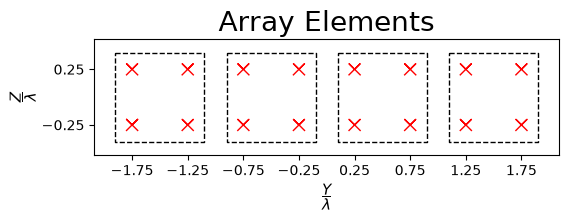

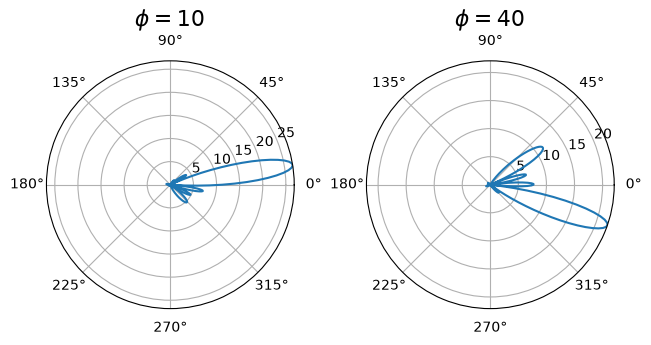

In [7]:
# Important note:
# This antenna array, with default internal precoders (B), behaves like a panel of 4 elements
# with 1λ spacing instead of 0.5λ. Since the spacing is larger than 0.5λ, grating lobes appear
# for some steering angles. This means we cannot reliably create beams at angles greater than 30°.

# Draw the antenna array:
txArray.showElements()

# Here is how two different beams look when using port-based precoding:
fig, ax = plt.subplots(1,2, layout='constrained', subplot_kw={'projection': 'polar'})
txArray.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=10$",
                      weights=txArray.b @ txArray.getPortSteeringVector(90,10).flatten(), ax=ax[0])
txArray.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=40$",
                      weights=txArray.b @ txArray.getPortSteeringVector(90,40).flatten(), ax=ax[1])


<PolarAxes: title={'center': '$\\phi=40$'}>

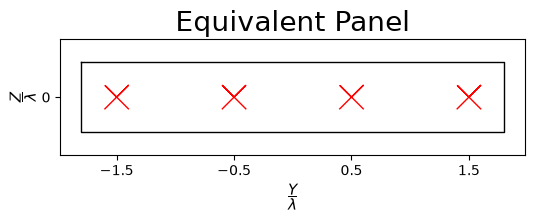

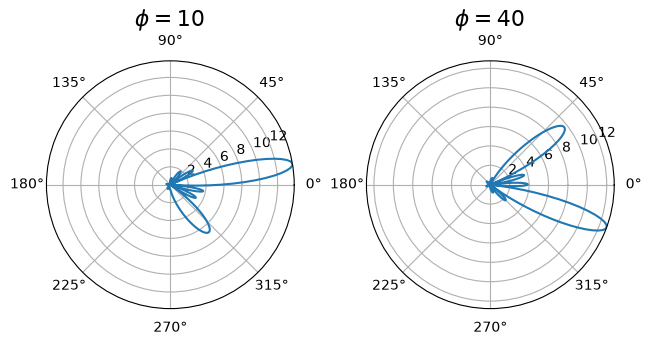

In [8]:
# To verify this, we can create a panel with 1λ spacing:
txPanel=AntennaPanel([1,4], polarization='x', spacing=(1,1))
txPanel.showElements(title="Equivalent Panel")

# Show the same two beams with this panel. As you can see the beams look very similar.
fig, ax = plt.subplots(1,2, layout='constrained', subplot_kw={'projection': 'polar'})
txPanel.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=10$",
                      weights=txPanel.getPortSteeringVector(90,10).flatten(), ax=ax[0])
txPanel.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=40$",
                      weights=txPanel.getPortSteeringVector(90,40).flatten(), ax=ax[1])

<PolarAxes: title={'center': '$\\phi=40$'}>

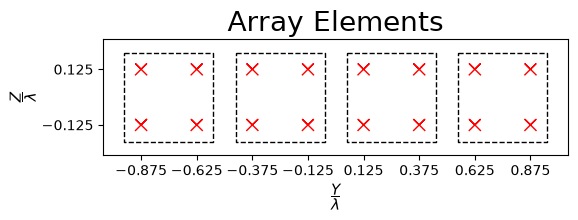

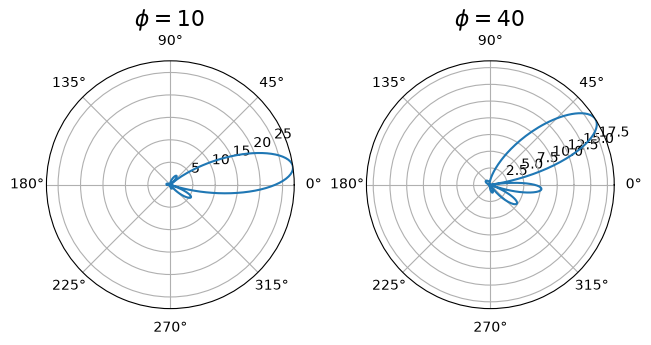

In [9]:
# One way to address this problem is to reduce the antenna spacing within each panel. 
# For example, we use antenna panels with an internal spacing of 0.25λ. In this 
# configuration, the panel centers are separated by 0.5λ, enabling the array to 
# perform beamforming over larger angles.
panelTemplate = AntennaPanel([2,2], spacing=[0.25,0.25], polarization="x")
txArray = AntennaArray([1,4], panels=panelTemplate)

# Draw the antenna array:
txArray.showElements()

# Here is how two different beams look when using port-based precoding:
fig, ax = plt.subplots(1,2, layout='constrained', subplot_kw={'projection': 'polar'})
txArray.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=10$",
                      weights=txArray.b @ txArray.getPortSteeringVector(90,10).flatten(), ax=ax[0])
txArray.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=40$",
                      weights=txArray.b @ txArray.getPortSteeringVector(90,40).flatten(), ax=ax[1])
                      

<PolarAxes: title={'center': '$\\phi=40$'}>

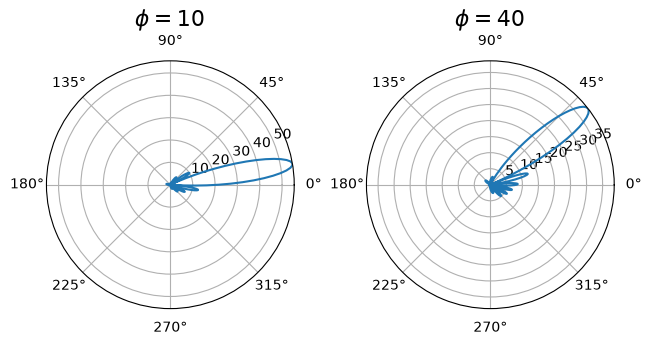

In [10]:
# Another option is to use element-based precoding, which enables beam steering over larger 
# angles with narrower beams. This is because the element spacing remains 0.5λ, while the 
# weights of individual elements can be controlled independently.

panelTemplate = AntennaPanel([2,2], polarization="x")
txArray = AntennaArray([1,4], panels=panelTemplate)

# Here is how the same beams look:
fig, ax = plt.subplots(1,2, layout='constrained', subplot_kw={'projection': 'polar'})
txArray.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=10$",
                      weights=txArray.getSteeringVector(90,10).conj().flatten(), ax=ax[0])
txArray.drawRadiation(theta=90, radiationType="Field", normalize=False, title = "$\\phi=40$",
                      weights=txArray.getSteeringVector(90,40).conj().flatten(), ax=ax[1])